In [1]:
print("Hello")

Hello


In [2]:
# Autoreload files
%load_ext autoreload
%autoreload 2

#import camera_module
import os

import numpy as np
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"

import cv2
import matplotlib.pyplot as plt
import rawpy
# import camera simulation code
import camera_simulation as sim
import image_comparer as comp
from pathlib import Path
from itertools import product
from tqdm import tqdm

base_path = Path.cwd()
print(base_path)
path_to_exr_images = Path("H:/Subset/HDR_EXR")
path_to_cam_images = Path("H:/kamera_bilder_meta")
path_to_printed_images = Path("H:/gedruckt")
path_to_rectified_images = Path("H:printed_rectified")
path_to_ssd = Path("H:")

img_path = "example_images/h_1000002_12.exr"
depth_path = "example_images/d_1000002.exr"

img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
depth = cv2.imread(depth_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
if img is None:
    print("CV2 not loaded correctly")


c:\CodeStuff\RDR2-RA\camera_simulation
CV2 not loaded correctly


### Show exr images

In [ ]:
img_path = "example_images/h_1000002_12.exr"
img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #  type: ignore
print(img.shape)
print(img.dtype)
print(img[0, 0, 0])

(1440, 2560, 3)
float32
0.1748352


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01083374..1.1378174].


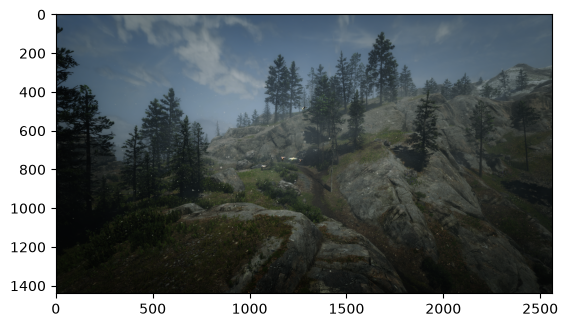

In [ ]:
# plot image using matplotlib
plt.imshow(img) # type: ignore
plt.show()

### Simulate Camera

#### Plot single example simulation

Image shape: (1440, 2560, 3)
Image dtype: float32
Pixel value range: 54.168701171875 to 5689.0869140625
Mean pixel value: 1215.798828125
Standard deviation of pixel values: 787.6151123046875
Image shape: (1440, 2560, 3)
Image dtype: float64
Pixel value range: 30.799999999999997 to 4296.599999999999
Mean pixel value: 902.3821691713686
Standard deviation of pixel values: 585.1262277056883
Image shape: (1440, 2560, 3)
Image dtype: uint8
Pixel value range: 0 to 116
Mean pixel value: 23.949034288194444
Standard deviation of pixel values: 15.856030548671328


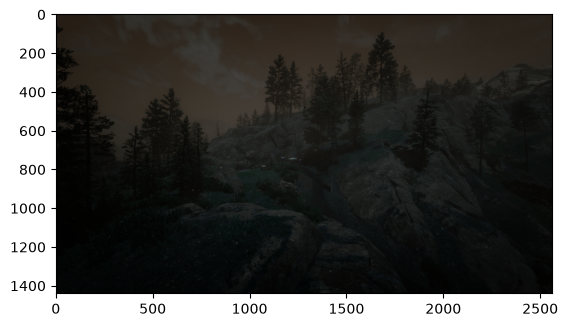

In [2]:

if img is None:
    print(f"Failed to load image from {img_path}")

else:
    # create camera simulation object
    camera_sim = sim.CameraSimulation(iso = sim.iso_values[0], log=True)
    # simulate camera response
    simulated_img = camera_sim.simulate_image(img*5000, depth)
    # plot simulated image
    plt.imshow(simulated_img)
    plt.show()

#### Plot example simulation all params

250 0.25 5.0
250 0.25 9.0
250 0.25 16.0
250 0.016666666666666666 5.0
250 0.016666666666666666 9.0
250 0.016666666666666666 16.0
250 0.001 5.0
250 0.001 9.0
250 0.001 16.0
2000 0.25 5.0
2000 0.25 9.0
2000 0.25 16.0
2000 0.016666666666666666 5.0
2000 0.016666666666666666 9.0
2000 0.016666666666666666 16.0
2000 0.001 5.0
2000 0.001 9.0
2000 0.001 16.0
16000 0.25 5.0
16000 0.25 9.0
16000 0.25 16.0
16000 0.016666666666666666 5.0
16000 0.016666666666666666 9.0
16000 0.016666666666666666 16.0
16000 0.001 5.0
16000 0.001 9.0
16000 0.001 16.0


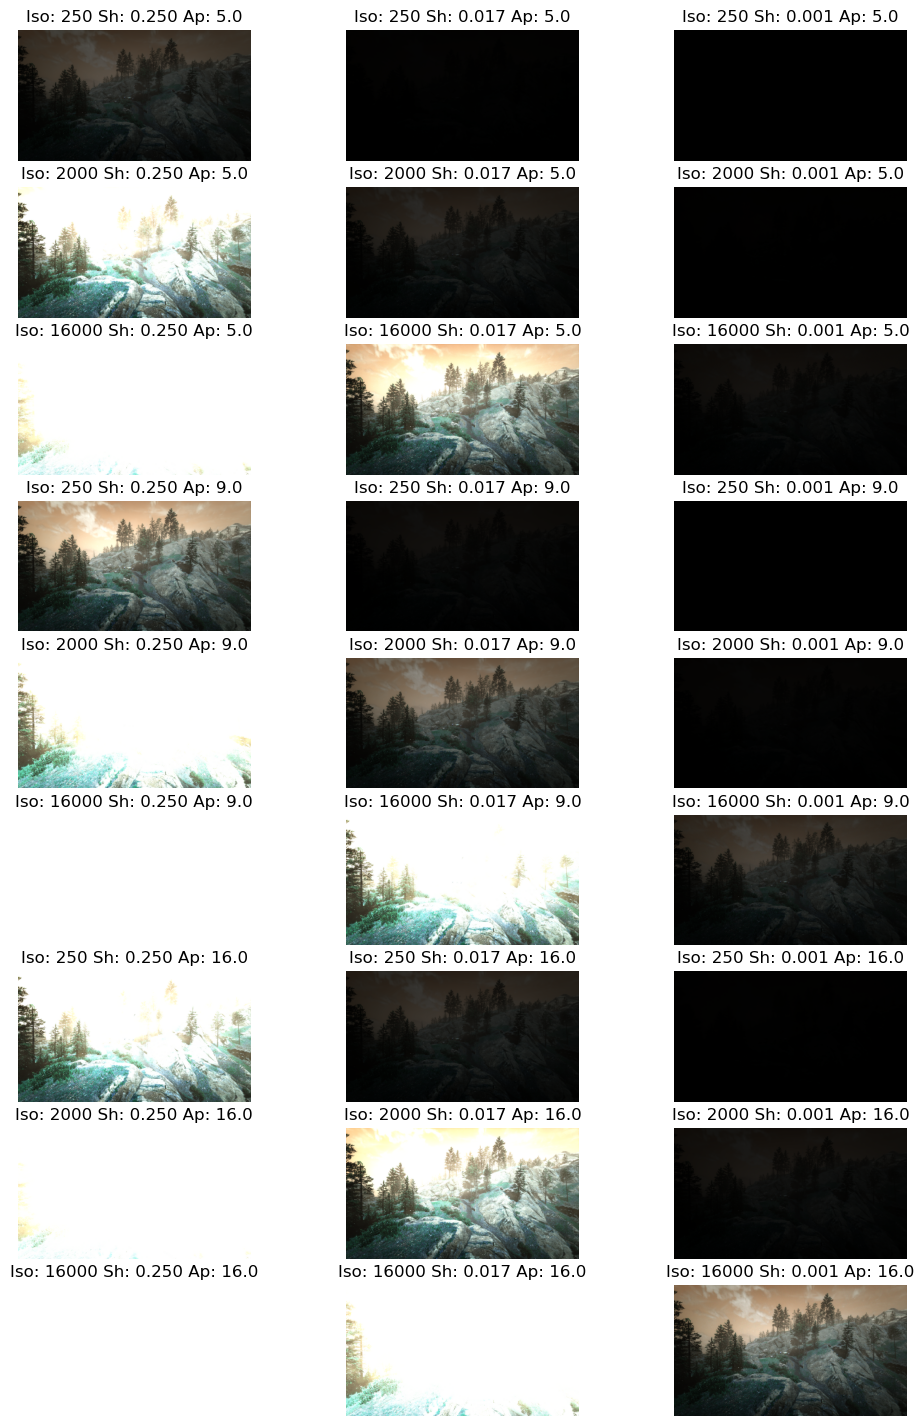

In [ ]:
fig, ax = plt.subplots(9,3, figsize=(12,18))

cam = sim.CameraSimulation(log=False)
images = []

for i in range(3):
    for j in range(3):
        for k in range(3):
            iso = sim.iso_values[i]
            shutter_speed = sim.shutter_speed_values[j]
            aperture = sim.aperture_values[k]
            print(iso, shutter_speed, aperture)
            cam.set_parameters(iso=iso, shutter_speed=shutter_speed, aperture=aperture)
            simulation = cam.simulate_image(img*5000, depth)
            ax[k*3+i][j].imshow(simulation)
            ax[k*3+i][j].axis('off')
            ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")



plt.show()


#### Plot any file all params

Simulating Camera Parameters: 100%|██████████| 27/27 [00:35<00:00,  1.31s/it]


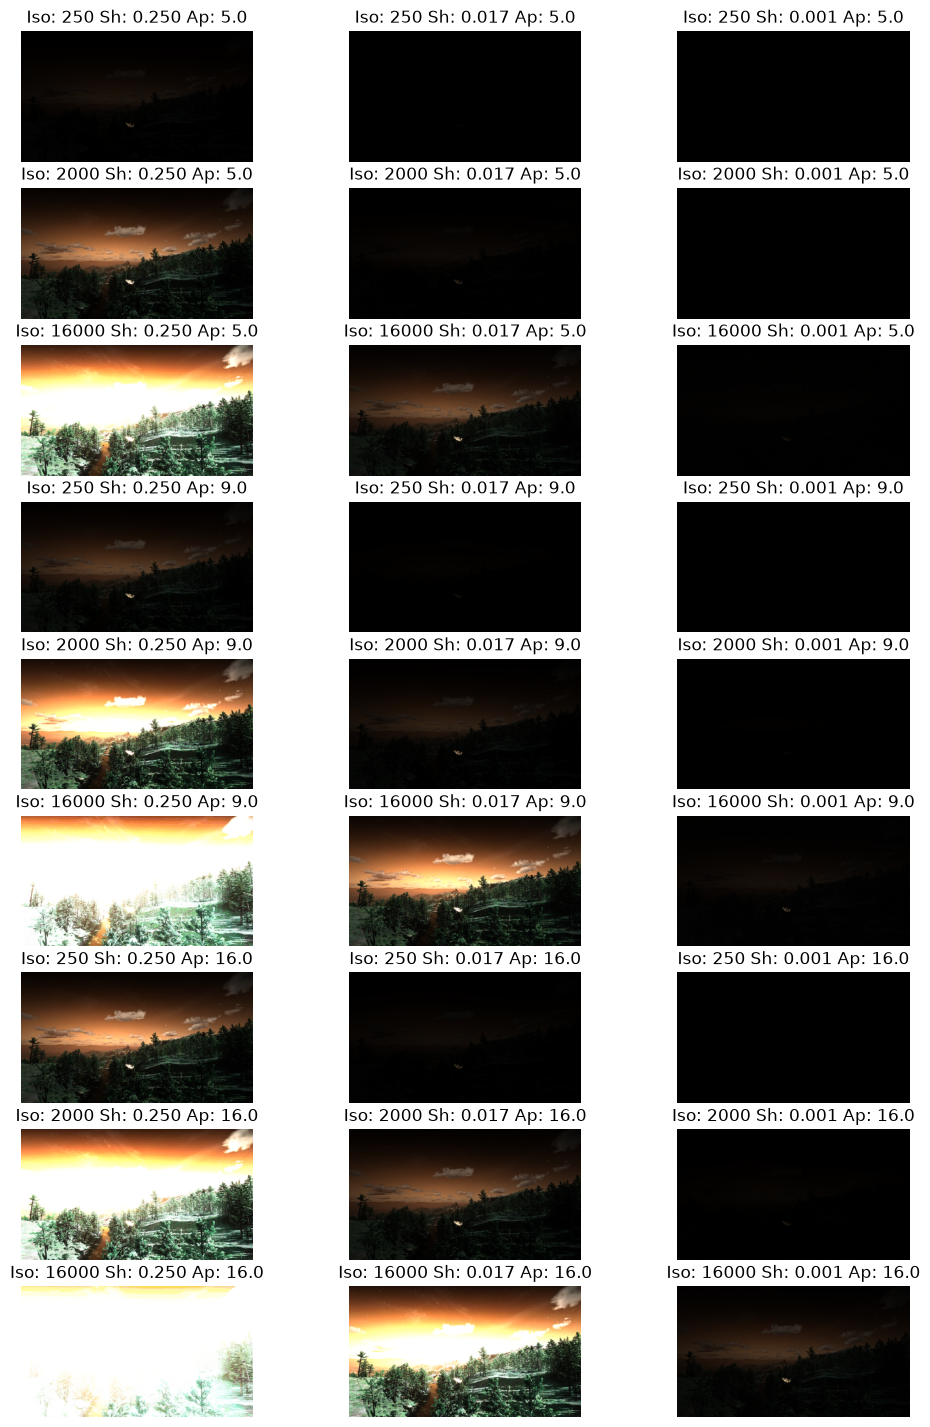

In [ ]:
filename="h_1000131_0.exr"
input_factor = 5000
filepath = path_to_exr_images/filename
img = cv2.imread(filepath, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)*input_factor
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #  type: ignore

fig, ax = plt.subplots(9,3, figsize=(12,18))
plt.title(f"File {filename} simulated with input_factor {input_factor}")
simulator = sim.CameraSimulation(log=False)

for i, j, k in tqdm(product(range(3), range(3), range(3)), total=27, desc="Simulating Camera Parameters"):
    iso = sim.iso_values[i]
    shutter_speed = sim.shutter_speed_values[j]
    aperture = sim.aperture_values[k]
    simulator.set_parameters(iso=iso, shutter_speed=shutter_speed, aperture=aperture)
    simulation = simulator.simulate_image(img, 0)
    ax[k*3+i][j].imshow(simulation)
    ax[k*3+i][j].axis('off')
    ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")


plt.savefig(filename.split(".")[0] + f"_sim{input_factor}_plot.png", bbox_inches=None)
plt.show()

#### Plot img from npy

In [3]:
orig_image_name = "h_1000131_20"
for i, input_factor in enumerate(range(1000, 12001, 1000)):#[1000, 2000, 3000, 4000, 6000]):
    filepath =f"H:/sim imgs npy/{orig_image_name}/{orig_image_name}_{input_factor}_imgs.npy"  # f"example_images/numpy_files/sim_images/{orig_image_name}/{orig_image_name}_{input_factor}_imgs.npy"
    imgs = np.load(filepath)

    fig, ax = plt.subplots(9,3, figsize=(12,18))
    plt.suptitle(f"File {orig_image_name} simulated with input_factor {input_factor}")
    simulator = sim.CameraSimulation(log=False)

    for i, j, k in tqdm(product(range(3), range(3), range(3)), total=27, desc="Preparing Plot with Simulations"):
        iso = sim.iso_values[i]
        shutter_speed = sim.shutter_speed_values[j]
        shutter_speed_str = sim.shutter_speed_values_str[j]
        aperture = sim.aperture_values[k]
        
        simulation = imgs[i][k][j].astype(np.uint8)
        ax[k*3+i][j].imshow(simulation)
        ax[k*3+i][j].axis('off')
        ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")
    plt.tight_layout()
    plt.savefig(f"Sim_plots/{orig_image_name}_sim{input_factor}_plot.png", bbox_inches=None)
    plt.close()

Preparing Plot with Simulations: 100%|██████████| 27/27 [00:00<00:00, 41.04it/s]


### Read RAW ARW files

In [ ]:


with rawpy.imread("H:/kamera_bilder_meta/ottoturm_hell/ISO250_F9_sh1-60.ARW") as raw:
    rgb = raw.postprocess(
        use_camera_wb=False,
        use_auto_wb=False,
        no_auto_bright=True,
        output_bps=16,
        gamma=(1, 1),      # linear
        bright=1.0,
        user_flip=0,
        demosaic_algorithm=rawpy.DemosaicAlgorithm.DCB
    )

AttributeError: 'int' object has no attribute 'checkSupported'

In [4]:
print(rgb.shape)
print(np.max(rgb))

(4024, 6024, 3)
65535


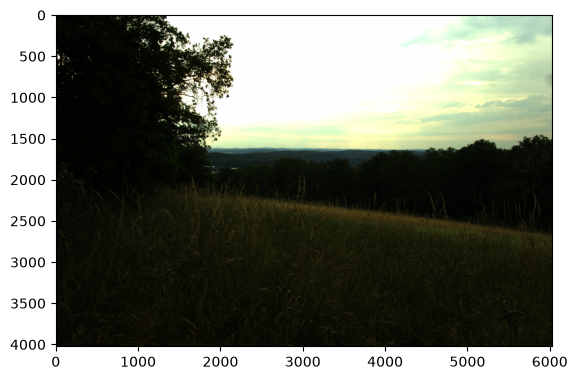

In [6]:
import matplotlib.pyplot as plt

import numpy as np


rgb_norm = (rgb/65535)#np.max(rgb))

plt.imshow(rgb_norm)
plt.show()

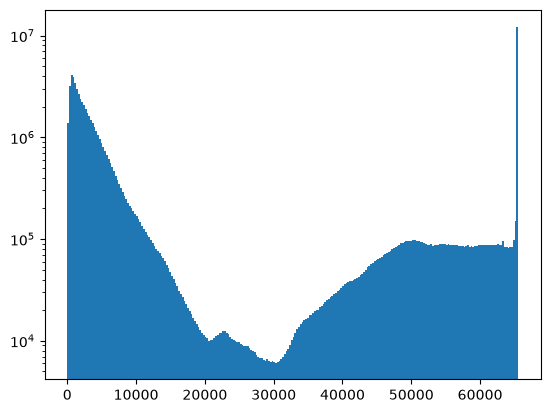

In [10]:
plt.hist(rgb.flatten(), 256)
plt.yscale("log")
plt.show()

65536

### Plot ARW Files

In [2]:
directories = [str(f.name) for f in path_to_printed_images.iterdir() if not f.is_file()]

for image_name in tqdm(directories): #["wellersberg_hundeschule_nacht", "wellersberg_stadt_abend", "wellersberg_stadt_nacht"]:
    image_path = path_to_printed_images / image_name
    print(image_name)
    imgs = comp.load_image_files_to_matrix(image_path, extension="png", hw=(4000, 6000))#.astype(np.uint8)

    fig, ax = plt.subplots(9,3, figsize=(12,18))

    plt.title(image_name)
    for i in range(3):
        for j in range(3):
            for k in range(3):
                iso = sim.iso_values[i]
                shutter_speed = sim.shutter_speed_values[j]
                aperture = sim.aperture_values[k]
                image = imgs[i][k][j]#.astype(np.uint8)
                ax[k*3+i][j].imshow(image)
                ax[k*3+i][j].axis('off')
                ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")
    plt.tight_layout()
    plt.savefig("Cam_plots_printed_JPEG/" + image_name + "_plot.pdf", bbox_inches=None)
    plt.close(fig)
    print(f"{image_name} Plot Saved")
    print("*"*50)
#plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

h_1000131_20


  0%|          | 0/3 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'H:\\gedruckt\\h_1000131_20\\ISO250_F5_sh1-4.png'

In [2]:
#directories = [str(f.name) for f in path_to_cam_images.iterdir() if not f.is_file()]

#for image_name in tqdm(directories):
#image_path = path_to_cam_images / image_name
image_path = Path("H:/sim_imgs_npy/h_1000131_20/")
files = [f for f in image_path.iterdir()]
for file in tqdm(files):
    image_name = str(file.name).split(".")[0]
    imgs = np.load(file).astype(np.uint8)#comp.load_image_files_to_matrix(image_path, extension="npy", hw=(4000, 6000), target_hw=(400,600))#.astype(np.uint8)
    
    imgs_small = np.zeros((3,3,3, 400, 600, 3))
    for i,j,k in product(range(3), range(3), range(3)):
        imgs_small[i][j][k] = cv2.resize(imgs[i][j][k],(600, 400)).astype(np.uint8)

    
    np.save(f"example_images/numpy_files/sim_images/h_1000131_20/{image_name}_small", imgs_small)
    fig, ax = plt.subplots(3,9, figsize=(18,4))

    #plt.title(image_name)
    for i in range(3):
        for j in range(3):
            for k in range(3):
                iso = sim.iso_values[i]
                shutter_speed = sim.shutter_speed_values[j]
                aperture = sim.aperture_values[k]
                image = imgs[i][k][j]#.astype(np.uint8)
                ax[i][k*3+j].imshow(image)
                ax[i][k*3+j].axis('off')
    plt.tight_layout()
    plt.savefig("Sim_plots_Small/" + image_name + "_plot.pdf", bbox_inches=None)
    plt.close(fig)
    #print(f"{image_name} Plot Saved")
    #print("*"*50)
#plt.show()

100%|██████████| 16/16 [06:30<00:00, 24.43s/it]


### Compare Sim and Cam

#### Save arw files normalized histograms in npy matrix

In [4]:
for name in ["wellersberg_stadt_nacht", "wellersberg_wald_abend", "wellersberg_wald_nacht"]:
    print(name)
    imgs = comp.load_image_files_to_matrix(Path("H:/kamera_bilder_meta/" + name))
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32))
    np.save('example_images/' + name, hists)
print("done")

wellersberg_stadt_nacht


100%|██████████| 27/27 [00:01<00:00, 16.49it/s]


wellersberg_wald_abend


100%|██████████| 27/27 [00:01<00:00, 18.00it/s]


wellersberg_wald_nacht


100%|██████████| 27/27 [00:01<00:00, 16.41it/s]


done


#### Simulate images and save histframs in npy matrix

In [ ]:
input_factor = 5000
exr_directory = Path("H:/example_images/")
npy_dir = Path("./example_images/numpy_files/sim_images") / str(input_factor)
files = [f.stem for f in exr_directory.iterdir() if f.is_file()]
created_files = [f.stem for f in npy_dir.iterdir() if f.is_file()]
for name in tqdm(files, desc="Files"):
    if name in created_files:
        print(f"Skipping {name}, as it already exists")
        continue
    print(f"Create {name} Matrix")
    imgs = comp.simulate_images(exr_directory / (name + ".exr"))
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32), val_range=[0,256])
    np.save(npy_dir / name.split(".")[0], hists)
print("done")

Files:   0%|          | 0/55 [00:00<?, ?it/s]

Create h_1000131_0 Matrix


Files:   2%|▏         | 1/55 [00:32<29:23, 32.66s/it]

Create h_1000131_12 Matrix


Files:   4%|▎         | 2/55 [01:04<28:32, 32.31s/it]

...

Create h_1036201_20 Matrix


Files:  98%|█████████▊| 54/55 [15:42<00:19, 19.84s/it]

Create h_1036201_7 Matrix


Files: 100%|██████████| 55/55 [16:15<00:00, 17.74s/it]

done


In [5]:
input_factors = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000]
name = "h_1000131_20"
npy_dir_repo = Path(f"./example_images/numpy_files/sim_images/{name}/")
npy_dir_ssd = path_to_ssd / "/sim_imgs_npy" / str(name)
for factor in tqdm(input_factors, desc="Files"):
    #print(f"Create {name} Matrix")
    imgs = comp.simulate_images(path_to_exr_images /  (name + ".exr"), input_factor=factor)
    np.save(npy_dir_ssd /(name + "_" + str(factor) + "_imgs"), imgs)
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32), val_range=[0,256])
    np.save(npy_dir_repo /(name + "_" + str(factor) + "_hist"), hists)
print("done")

Files: 100%|██████████| 16/16 [10:14<00:00, 38.43s/it]

done


#### Compare from npy files

##### Create comparison Matrix for one simulation

In [9]:
sim_path = base_path / "example_images/numpy_files/sim_images/h_1000131_20/h_1000131_20_2000_hist.npy"
cam_path = base_path / "example_images/numpy_files/cam_images/wellersberg_wald_abend_hist.npy"
comparison_matrix = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
#print(comparison_matrix)
print(np.average(comparison_matrix))

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]

0.48774546


##### Plot Comparison values

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\2146730559.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


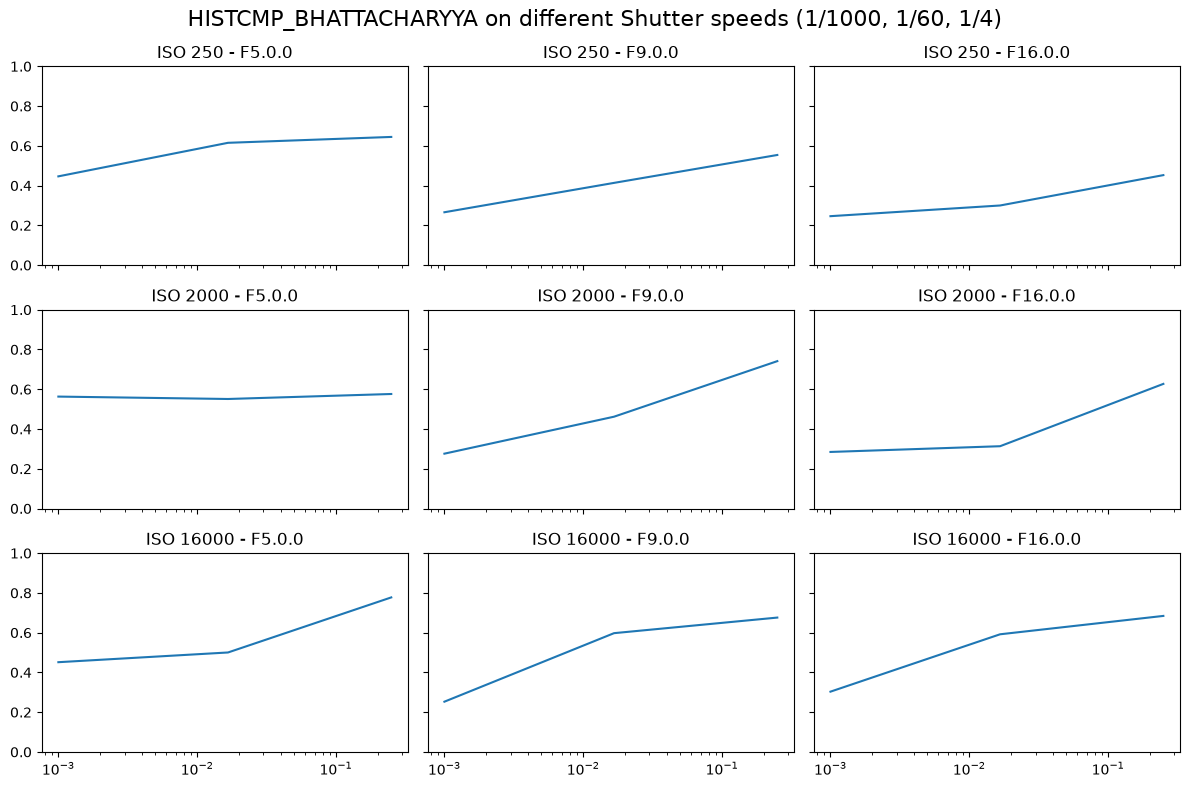

In [14]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
for i in range(3):
    for j in range(3):
        ax[i][j].plot(shs, comparison_matrix[i][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"ISO {isos[i]} - F{fs[j]}.0")
fig.suptitle("HISTCMP_BHATTACHARYYA on different Shutter speeds (1/1000, 1/60, 1/4)", fontsize=16)
plt.tight_layout()

fig.show()

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\2920192100.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


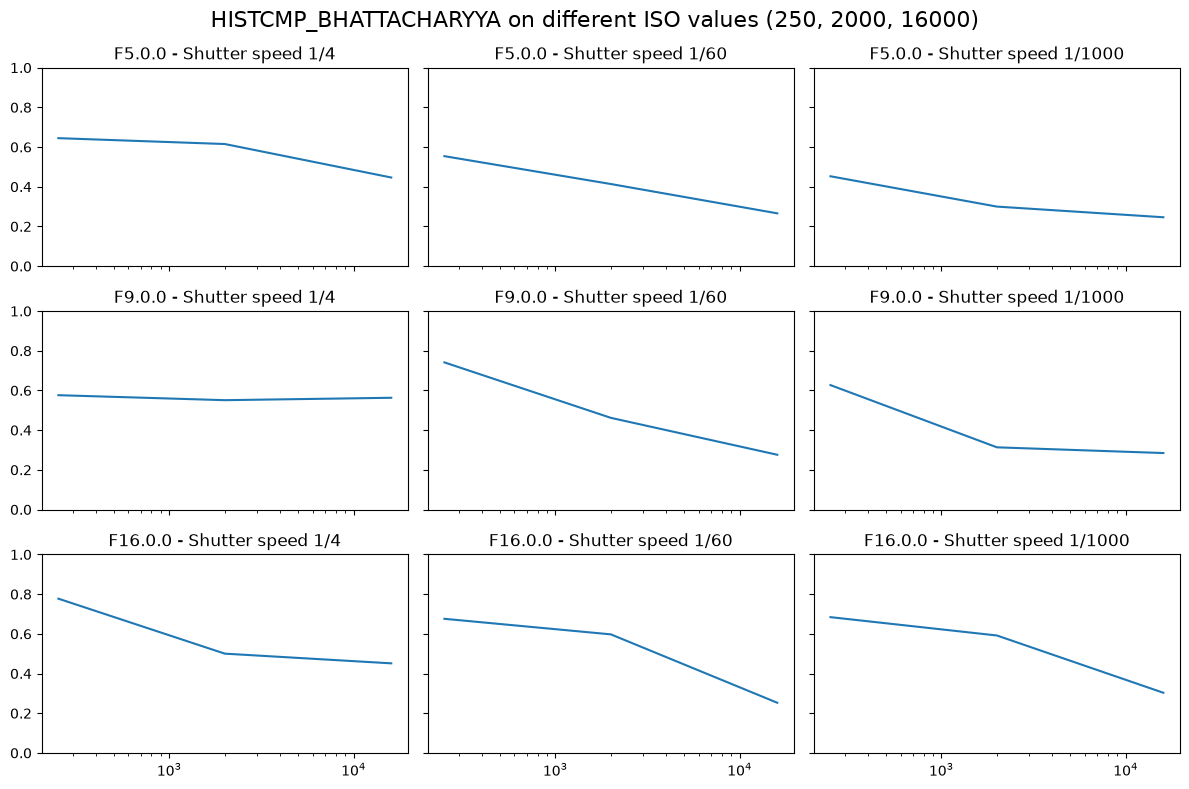

In [18]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
shs_str = sim.shutter_speed_values_str
for i in range(3):
    for j in range(3):
        ax[i][j].plot(isos, comparison_matrix[:][i][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"F{fs[i]}.0 - Shutter speed {shs_str[j]}")
fig.suptitle("HISTCMP_BHATTACHARYYA on different ISO values (250, 2000, 16000)", fontsize=16)
plt.tight_layout()

fig.show()

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\3805821002.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


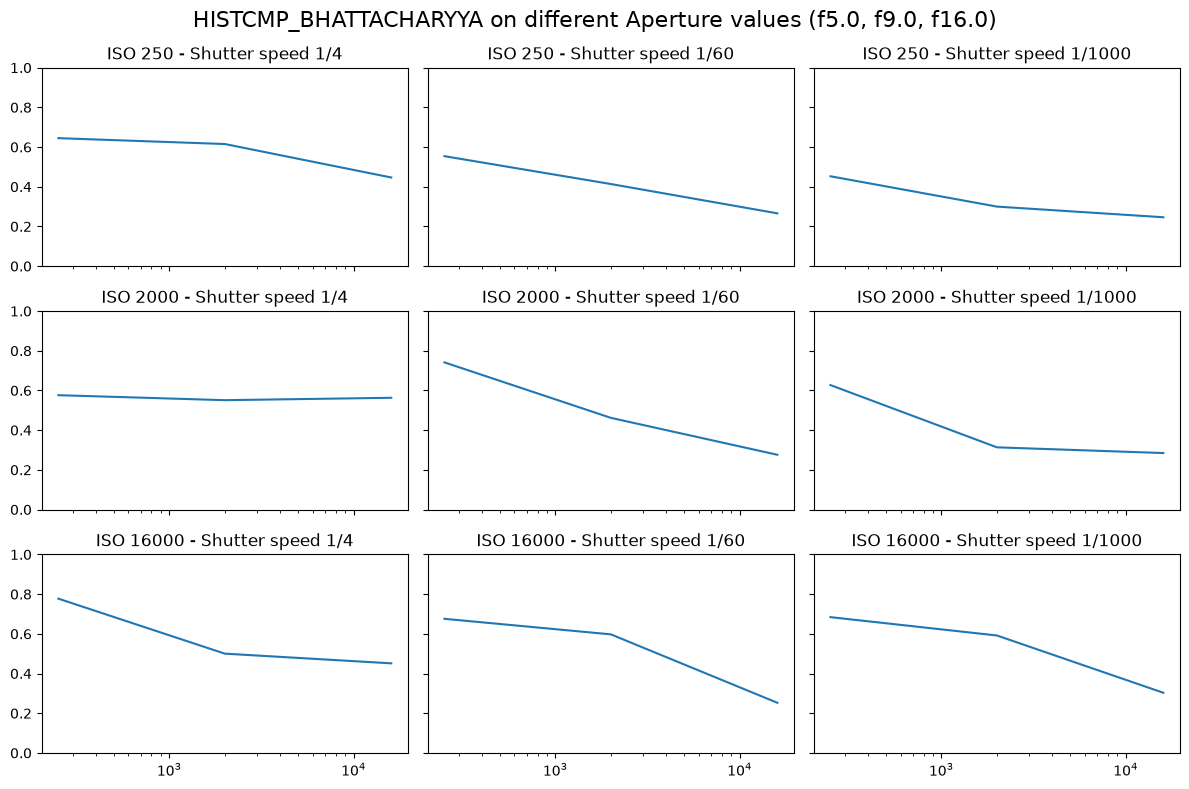

In [19]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
shs_str = sim.shutter_speed_values_str
for i in range(3):
    for j in range(3):
        ax[i][j].plot(isos, comparison_matrix[i][:][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"ISO {isos[i]} - Shutter speed {shs_str[j]}")
fig.suptitle("HISTCMP_BHATTACHARYYA on different Aperture values (f5.0, f9.0, f16.0)", fontsize=16)
plt.tight_layout()

fig.show()

In [ ]:
cam_path = base_path / "example_images/numpy_files/cam_images/wellersberg_wald_abend_hist.npy"
comps_avg = {}
comps = {}
input_factors = [1000, 2000, 3000, 4000, 5000, 6000]
for f in input_factors:

    sim_path = base_path / f"example_images/numpy_files/sim_images/h_1000131_20/h_1000131_20_{f}_hist.npy"
    comparison_matrix = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    comps[f] = comparison_matrix
    comps_avg[f] = np.average(comparison_matrix) 

#print(comparison_matrix)
print(comps_avg)

NameError: name 'input_factors' is not defined

##### Compare Histogramms over several Simulations

[0.49024016 0.43554196 0.417      0.40999109 0.40723334 0.40661186
 0.40664235 0.40795204 0.40999983 0.41261916 0.41537833 0.41819547
 0.4211989  0.42419324 0.42690791 0.42978266]
[0.5381974  0.50177937 0.49165933 0.48789709 0.48747644 0.48884813
 0.49062644 0.49283706 0.49536757 0.49789667 0.50021071 0.50246212
 0.50465172 0.50658216 0.50820532 0.51000852]
[0.90756681 0.84111646 0.82290775 0.82128718 0.83122409 0.84926374
 0.86961748 0.8898991  0.91085469 0.93238203 0.95328656 0.97401899
 0.99497389 1.01511925 1.0335773  1.05199733]


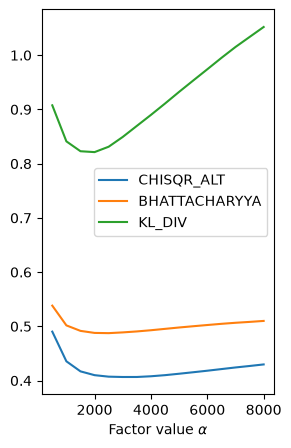

In [4]:

comp_cam_img = "wellersberg_wald_abend"
orig_image_name = "h_1000131_20"
factor_values = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000]
avg_results_1 = np.zeros(len(factor_values))
avg_results_2 = np.zeros(len(factor_values))
avg_results_3 = np.zeros(len(factor_values))
comparison_matrices_1 = np.zeros((len(factor_values),3,3,3,1)) 
comparison_matrices_2 = np.zeros((len(factor_values),3,3,3,1)) 
comparison_matrices_3 = np.zeros((len(factor_values),3,3,3,1)) 


for i, val in enumerate(factor_values):
    sim_path = base_path / f"example_images/numpy_files/sim_images/{orig_image_name}/{orig_image_name}_{val}_hist.npy"
    cam_path = base_path / f"example_images/numpy_files/cam_images/{comp_cam_img}_hist.npy"
    comparison_matrices_1[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_CHISQR_ALT)
    comparison_matrices_2[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    comparison_matrices_3[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_KL_DIV)
    avg_results_1[i] = np.average(comparison_matrices_1[i])
    avg_results_2[i] = np.average(comparison_matrices_2[i])
    avg_results_3[i] = np.average(comparison_matrices_3[i])
fig = plt.figure(figsize=(3,5))
plt.plot(factor_values, avg_results_1, label="CHISQR_ALT")
plt.plot(factor_values, avg_results_2, label="BHATTACHARYYA")
plt.plot(factor_values, avg_results_3, label="KL_DIV")
print(avg_results_1)
print(avg_results_2)
print(avg_results_3)
plt.xlabel("Factor value $\\alpha$")
plt.legend()
#plt.title(f"Avg Histogram comparison over Factor Values\nComparing {comp_cam_img} and {orig_image_name}")
plt.savefig(f"Histogramm_comparison {comp_cam_img} {orig_image_name}.pdf")
plt.show()

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<00:00, 38584.74it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


...

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<00:00, 27001.96it/s]

[0.49516833 0.48774552 0.49208214 0.49841487 0.50414069 0.50876252
 0.5141008  0.5190645  0.52436154 0.5297787 ]


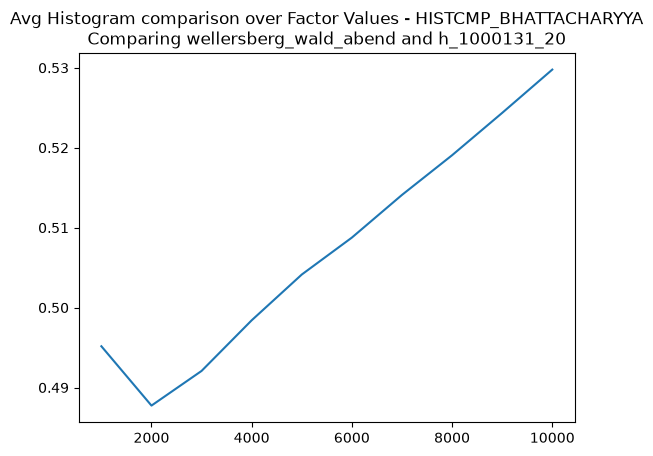

In [6]:
avg_results = np.zeros(len(factor_values))
comparison_matrices = np.zeros((len(factor_values),3,3,3,1)) 
for i, val in enumerate(factor_values):
    sim_path = base_path / f"example_images/numpy_files/sim_images/{orig_image_name}/{orig_image_name}_{val}_hist.npy"
    cam_path = base_path / f"example_images/numpy_files/cam_images/{comp_cam_img}_hist.npy"
    comparison_matrices[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    avg_results[i] = np.average(comparison_matrices[i])
print(avg_results)
plt.plot(factor_values, avg_results)
plt.title(f"Avg Histogram comparison over Factor Values - HISTCMP_BHATTACHARYYA\nComparing {comp_cam_img} and {orig_image_name}")

plt.show()

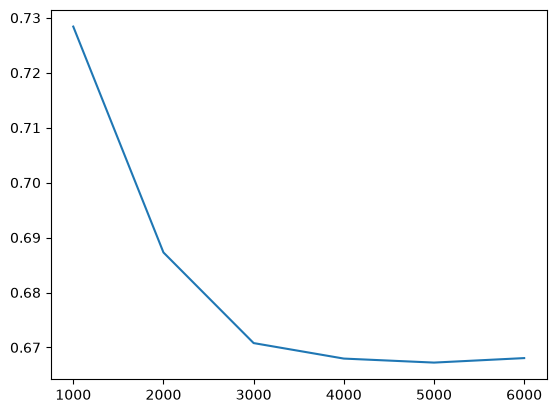

In [9]:
plt.plot([1000, 2000, 3000, 4000, 5000, 6000], avg_results)
plt.show()

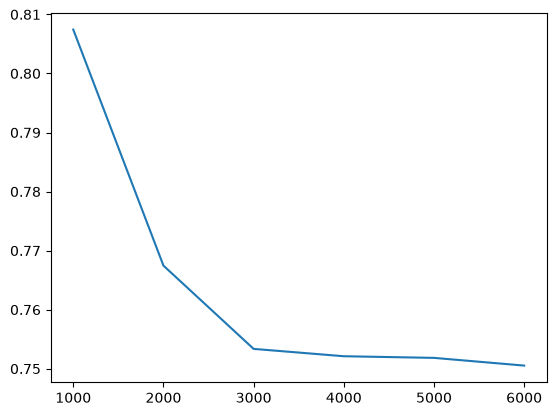

In [7]:
plt.plot([1000, 2000, 3000, 4000, 5000, 6000], avg_results)
plt.show()

### Fix perspective of printed photos

In [8]:
dir_name = "weiss"

# Four corners in the photo (pixel coordinates)
src_pts = np.asarray([
    [578, 560],   # TL
    [5361, 723],   # TR
    [5561, 3488],   # BR
    [656, 3626]   # BL
], dtype=np.float32)

# Desired output size
width = 6000
height = 4000

dst_pts = np.asarray([
    [0, 0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0, height - 1]
], dtype=np.float32)

# Compute perspective transform
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

for i, j, k in tqdm(product(range(3), range(3), range(3)), total=27):
    iso = sim.iso_values[i]
    f = int(sim.aperture_values[j])
    sh_str = sim.shutter_speed_values_str[k].replace("/", "-")
    # Load image
    path = path_to_printed_images / f"{dir_name}/ISO{iso}_F{f}_sh{sh_str}.ARW"
    img = comp.load_arw_file(path, norm_factor=1)

    # Warp image
    rectified = cv2.warpPerspective(img, H, (width, height))
    rectified = cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB) #  type: ignore
    #plt.imshow(rectified)
    cv2.imwrite(f"H:/printed_rectified/{dir_name}/ISO{iso}_F{f}_sh{sh_str}.png", rectified)

100%|██████████| 27/27 [02:17<00:00,  5.10s/it]


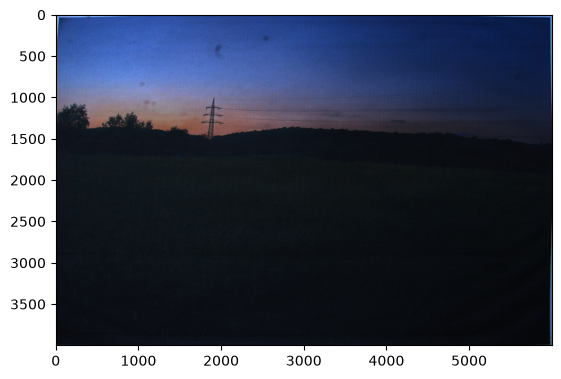

In [26]:
iso = sim.iso_values[0]
f = int(sim.aperture_values[0])
sh_str = sim.shutter_speed_values_str[1].replace("/", "-")
read = plt.imread(f"H:/printed_rectified/{dir_name}/ISO{iso}_F{f}_sh{sh_str}.png")
plt.imshow(read)